# 04. Modelamiento de la dependencia entre duración y severidad mediante cópulas (nSPEI-3)

Versión corregida para mantener la trazabilidad con el ajuste marginal definitivo.

Flujo:

1. Lee los eventos nSPEI-3.
2. Lee las distribuciones marginales seleccionadas en el Bloque 03.
3. Usa los parámetros MLE finales del Bloque 03 para transformar duración y severidad al espacio uniforme.
4. Ajusta cinco familias de cópulas: Clayton, Frank, Gumbel, Gaussiana y t-Student.
5. Selecciona por AIC y contrasta con BIC.
6. Calcula medidas de dependencia y dependencia de colas de la cópula seleccionada.
7. Genera tablas y figuras de forma dinámica: no se presupone que Gumbel sea la mejor familia.

Importante: las observaciones transformadas se obtienen mediante las CDF marginales paramétricas ajustadas, no mediante rangos empíricos.


In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  janitor,
  lmomco,
  copula,
  patchwork,
  plotly,
  htmlwidgets,
  viridisLite,
  cowplot
)


Cargando paquete requerido: pacman

Warning message:
"package 'pacman' was built under R version 4.5.3"


In [2]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

encontrar_raiz_proyecto <- function(inicio = getwd()) {
  marcadores <- c("01_datos", "02_scripts", "03_resultados", "04_documentacion")
  es_raiz <- function(x) all(dir.exists(file.path(x, marcadores)))

  raiz_env <- Sys.getenv("TESIS_SEQUIAS_ROOT", unset = "")
  if (nzchar(raiz_env)) {
    raiz_env <- normalizePath(raiz_env, winslash = "/", mustWork = FALSE)
    if (es_raiz(raiz_env)) return(raiz_env)
  }

  ruta <- normalizePath(inicio, winslash = "/", mustWork = TRUE)

  repeat {
    if (es_raiz(ruta)) return(ruta)

    padre <- dirname(ruta)
    if (identical(padre, ruta)) {
      stop(
        "No se encontró la raíz del proyecto. ",
        "Ejecute Jupyter dentro del repositorio o defina TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_procesados <- file.path(
  ruta_base, "01_datos", "procesados"
)

ruta_marginales <- file.path(
  ruta_base, "03_resultados", "03_marginales", "tablas"
)

ruta_tablas <- file.path(
  ruta_base, "03_resultados", "04_copulas", "tablas"
)

ruta_figuras <- file.path(
  ruta_base, "03_resultados", "04_copulas", "figuras"
)

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)

archivo_marginales <- file.path(
  ruta_marginales,
  "mejores_marginales_nspei3_por_cluster.csv"
)

dir.create(ruta_tablas, recursive = TRUE, showWarnings = FALSE)
dir.create(ruta_figuras, recursive = TRUE, showWarnings = FALSE)

cat("Archivo de eventos:", file.exists(archivo_eventos), "\n")
cat("Marginales finales:", file.exists(archivo_marginales), "\n")
cat("Ruta tablas:", ruta_tablas, "\n")
cat("Ruta figuras:", ruta_figuras, "\n")

if (!file.exists(archivo_eventos)) {
  stop("No se encontró el archivo de eventos.")
}

if (!file.exists(archivo_marginales)) {
  stop(
    "No se encontró el archivo de marginales finales. ",
    "Ejecute primero el Bloque 03 MLE corregido."
  )
}


Archivo de eventos: TRUE 
Marginales finales: TRUE 
Ruta tablas: h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/04_copulas/tablas 
Ruta figuras: h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/04_copulas/figuras 


In [3]:
# ============================================================
# 3. EVENTOS DE SEQUÍA nSPEI-3
# ============================================================

eventos <- read.csv(
  archivo_eventos,
  stringsAsFactors = FALSE
) %>%
  clean_names() %>%
  mutate(
    fecha_inicio = as.Date(fecha_inicio),
    fecha_fin = as.Date(fecha_fin),
    cluster_ward = as.integer(cluster_ward)
  )

eventos_3 <- eventos %>%
  filter(escala == "nspei_3") %>%
  filter(
    is.finite(duracion),
    is.finite(severidad),
    duracion > 0,
    severidad > 0
  )

tabla_eventos_copulas <- eventos_3 %>%
  count(cluster_ward, name = "numero_eventos") %>%
  transmute(
    cluster = cluster_ward,
    numero_eventos,
    escala = "nSPEI-3"
  )

write.csv(
  tabla_eventos_copulas,
  file.path(ruta_tablas, "eventos_ajuste_bivariado_nspei3.csv"),
  row.names = FALSE
)

tabla_eventos_copulas


cluster,numero_eventos,escala
<int>,<int>,<chr>
1,584,nSPEI-3
2,152,nSPEI-3
3,61,nSPEI-3


In [4]:
# ============================================================
# 4. MARGINALES MLE FINALES Y TRANSFORMACIÓN AL ESPACIO UNIFORME
# ============================================================

marginales_finales <- read.csv(
  archivo_marginales,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names()

# Se esperan las selecciones definitivas obtenidas en el Bloque 03:
# C1: D=LN3, S=LN3
# C2: D=LN3, S=LN3
# C3: D=LN3, S=GPA
esperado <- tibble(
  cluster = c(1, 1, 2, 2, 3, 3),
  variable_clave = c("D", "S", "D", "S", "D", "S"),
  modelo_esperado = c("LN3", "LN3", "LN3", "LN3", "LN3", "GPA")
)

# Normalización de columnas del CSV del Bloque 03.
marginales_finales <- marginales_finales %>%
  mutate(
    cluster = as.integer(stringr::str_extract(grupo, "\\d+")),
    variable_clave = if_else(
      stringr::str_detect(variable, regex("Duraci", ignore_case = TRUE)),
      "D",
      "S"
    ),
    modelo = toupper(modelo)
  )

verificacion_modelos <- marginales_finales %>%
  select(cluster, variable_clave, modelo) %>%
  left_join(
    esperado,
    by = c("cluster", "variable_clave")
  ) %>%
  mutate(coincide = modelo == modelo_esperado)

print(verificacion_modelos)

if (any(
  is.na(verificacion_modelos$coincide) |
  !verificacion_modelos$coincide
)) {
  stop(
    "Las marginales encontradas no coinciden con las marginales definitivas ",
    "del Bloque 03. Revise antes de continuar."
  )
}

# Convierte la cadena "p1, p2, p3" a vector numérico.
parsear_parametros <- function(x) {
  as.numeric(trimws(strsplit(x, ",", fixed = TRUE)[[1]]))
}

obtener_marginal <- function(cluster, variable_clave) {

  fila <- marginales_finales %>%
    filter(
      .data$cluster == .env$cluster,
      .data$variable_clave == .env$variable_clave
    )

  if (nrow(fila) != 1) {
    stop(
      "No se encontró exactamente una marginal para cluster ",
      cluster, " y variable ", variable_clave
    )
  }

  tipo <- tolower(fila$modelo[[1]])
  pars <- parsear_parametros(fila$parametros[[1]])

  par_obj <- lmomco::vec2par(
    pars,
    type = tipo
  )

  list(
    modelo = toupper(tipo),
    parametros = pars,
    par_obj = par_obj
  )
}

transformar_cluster <- function(datos, cluster, eps = 1e-8) {

  # Mantener duración y severidad como pares del mismo evento.
  datos_validos <- datos %>%
    transmute(
      duracion = as.numeric(duracion),
      severidad = as.numeric(severidad)
    ) %>%
    filter(
      is.finite(duracion),
      is.finite(severidad),
      duracion > 0,
      severidad > 0
    )

  md <- obtener_marginal(cluster, "D")
  ms <- obtener_marginal(cluster, "S")

  u_raw <- lmomco::plmomco(
    datos_validos$duracion,
    md$par_obj
  )

  v_raw <- lmomco::plmomco(
    datos_validos$severidad,
    ms$par_obj
  )

  if (
    any(!is.finite(u_raw)) ||
    any(!is.finite(v_raw))
  ) {
    stop(
      "Se obtuvieron CDF no finitas en el cluster ",
      cluster
    )
  }

  n_clip_u <- sum(u_raw <= eps | u_raw >= 1 - eps)
  n_clip_v <- sum(v_raw <= eps | v_raw >= 1 - eps)

  u <- pmin(pmax(u_raw, eps), 1 - eps)
  v <- pmin(pmax(v_raw, eps), 1 - eps)

  list(
    datos = tibble(
      duracion = datos_validos$duracion,
      severidad = datos_validos$severidad,
      u = u,
      v = v
    ),
    marginal_d = md$modelo,
    marginal_s = ms$modelo,
    n_clip_u = n_clip_u,
    n_clip_v = n_clip_v
  )
}

datos_c1 <- eventos_3 %>% filter(cluster_ward == 1)
datos_c2 <- eventos_3 %>% filter(cluster_ward == 2)
datos_c3 <- eventos_3 %>% filter(cluster_ward == 3)

tr_c1 <- transformar_cluster(datos_c1, 1)
tr_c2 <- transformar_cluster(datos_c2, 2)
tr_c3 <- transformar_cluster(datos_c3, 3)

pseudo_c1 <- tr_c1$datos
pseudo_c2 <- tr_c2$datos
pseudo_c3 <- tr_c3$datos

diagnostico_transformacion <- tibble(
  cluster = 1:3,
  marginal_duracion = c(tr_c1$marginal_d, tr_c2$marginal_d, tr_c3$marginal_d),
  marginal_severidad = c(tr_c1$marginal_s, tr_c2$marginal_s, tr_c3$marginal_s),
  n = c(nrow(pseudo_c1), nrow(pseudo_c2), nrow(pseudo_c3)),
  n_recortes_u = c(tr_c1$n_clip_u, tr_c2$n_clip_u, tr_c3$n_clip_u),
  n_recortes_v = c(tr_c1$n_clip_v, tr_c2$n_clip_v, tr_c3$n_clip_v),
  min_u = c(min(pseudo_c1$u), min(pseudo_c2$u), min(pseudo_c3$u)),
  max_u = c(max(pseudo_c1$u), max(pseudo_c2$u), max(pseudo_c3$u)),
  min_v = c(min(pseudo_c1$v), min(pseudo_c2$v), min(pseudo_c3$v)),
  max_v = c(max(pseudo_c1$v), max(pseudo_c2$v), max(pseudo_c3$v))
)

write.csv(
  diagnostico_transformacion,
  file.path(ruta_tablas, "diagnostico_transformacion_uniforme_nspei3.csv"),
  row.names = FALSE
)

diagnostico_transformacion


  cluster variable_clave modelo modelo_esperado coincide
1       1              D    LN3             LN3     TRUE
2       1              S    LN3             LN3     TRUE
3       2              D    LN3             LN3     TRUE
4       2              S    LN3             LN3     TRUE
5       3              D    LN3             LN3     TRUE
6       3              S    GPA             GPA     TRUE


cluster,marginal_duracion,marginal_severidad,n,n_recortes_u,n_recortes_v,min_u,max_u,min_v,max_v
<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,LN3,LN3,584,0,0,0.002365687,0.9974194,0.003957353,0.9978959
2,LN3,LN3,152,0,0,0.000632834,0.9971311,0.001230888,0.9976697
3,LN3,GPA,61,0,1,0.006270920,0.9816808,0.000000010,0.9899574


In [5]:
# ============================================================
# 5. AJUSTE DE CINCO FAMILIAS DE CÓPULAS
# ============================================================

ajustar_una_copula <- function(familia, uv) {

  tau_emp <- cor(
    uv[, 1],
    uv[, 2],
    method = "kendall",
    use = "complete.obs"
  )

  rho_ini <- sin(pi * tau_emp / 2)
  rho_ini <- min(max(rho_ini, -0.98), 0.98)

  crear <- switch(
    familia,

    "Clayton" = function() {
      theta0 <- tryCatch(
        iTau(claytonCopula(dim = 2), tau_emp),
        error = function(e) 1
      )
      list(
        cop = claytonCopula(dim = 2),
        start = max(theta0, 1e-4)
      )
    },

    "Frank" = function() {
      theta0 <- tryCatch(
        iTau(frankCopula(dim = 2), tau_emp),
        error = function(e) 1
      )
      list(
        cop = frankCopula(dim = 2),
        start = theta0
      )
    },

    "Gumbel" = function() {
      theta0 <- tryCatch(
        iTau(gumbelCopula(dim = 2), max(tau_emp, 1e-5)),
        error = function(e) 1.1
      )
      list(
        cop = gumbelCopula(dim = 2),
        start = max(theta0, 1.0001)
      )
    },

    "Gaussian" = function() {
      list(
        cop = normalCopula(dim = 2, dispstr = "un"),
        start = rho_ini
      )
    },

    "t-Student" = function() {
      list(
        cop = tCopula(
          dim = 2,
          dispstr = "un",
          df = 6,
          df.fixed = FALSE
        ),
        start = c(rho_ini, 6)
      )
    },

    stop("Familia no implementada: ", familia)
  )

  spec <- crear()

  fit <- tryCatch(
    suppressWarnings(
      fitCopula(
        spec$cop,
        uv,
        method = "ml",
        start = spec$start,
        estimate.variance = TRUE
      )
    ),
    error = function(e) NULL
  )

  if (is.null(fit)) {
    return(
      list(
        fila = tibble(
          familia = familia,
          logLik = NA_real_,
          AIC = Inf,
          BIC = Inf,
          k = NA_integer_,
          convergio = FALSE,
          parametro = NA_character_
        ),
        fit = NULL
      )
    )
  }

  ll <- as.numeric(logLik(fit))
  pars <- coef(fit)
  k <- length(pars)

  codigo <- tryCatch(
    fit@fitting.stats$convergence,
    error = function(e) 0
  )

  convergio <- is.finite(ll) && (is.null(codigo) || codigo == 0)

  fila <- tibble(
    familia = familia,
    logLik = ll,
    AIC = ifelse(convergio, -2 * ll + 2 * k, Inf),
    BIC = ifelse(convergio, -2 * ll + log(nrow(uv)) * k, Inf),
    k = k,
    convergio = convergio,
    parametro = paste(
      paste0(names(pars), "=", round(as.numeric(pars), 6)),
      collapse = "; "
    )
  )

  list(
    fila = fila,
    fit = if (convergio) fit else NULL
  )
}

ajustar_copulas_candidatas <- function(u, v) {

  uv <- cbind(u, v)

  if (
    any(!is.finite(uv)) ||
    any(uv <= 0) ||
    any(uv >= 1)
  ) {
    stop("Las observaciones transformadas deben pertenecer a (0,1).")
  }

  familias <- c(
    "Clayton",
    "Frank",
    "Gumbel",
    "Gaussian",
    "t-Student"
  )

  ajustes <- lapply(
    familias,
    ajustar_una_copula,
    uv = uv
  )

  tabla <- bind_rows(
    lapply(ajustes, `[[`, "fila")
  ) %>%
    arrange(AIC)

  modelos <- setNames(
    lapply(ajustes, `[[`, "fit"),
    familias
  )

  list(
    tabla = tabla,
    modelos = modelos
  )
}


In [6]:
# ============================================================
# 6. AJUSTE DE CÓPULAS POR CLUSTER
# ============================================================

cop_c1 <- ajustar_copulas_candidatas(pseudo_c1$u, pseudo_c1$v)
cop_c2 <- ajustar_copulas_candidatas(pseudo_c2$u, pseudo_c2$v)
cop_c3 <- ajustar_copulas_candidatas(pseudo_c3$u, pseudo_c3$v)

cat(
  "Cluster 1:", nrow(pseudo_c1), "eventos |",
  tr_c1$marginal_d, "/", tr_c1$marginal_s, "\n"
)

cat(
  "Cluster 2:", nrow(pseudo_c2), "eventos |",
  tr_c2$marginal_d, "/", tr_c2$marginal_s, "\n"
)

cat(
  "Cluster 3:", nrow(pseudo_c3), "eventos |",
  tr_c3$marginal_d, "/", tr_c3$marginal_s, "\n"
)


Cluster 1: 584 eventos | LN3 / LN3 
Cluster 2: 152 eventos | LN3 / LN3 
Cluster 3: 61 eventos | LN3 / GPA 


In [7]:
# ============================================================
# 7. COMPARACIÓN DE FAMILIAS DE CÓPULAS
# ============================================================

tabla_comparacion_copulas <- bind_rows(
  cop_c1$tabla %>% mutate(cluster = 1),
  cop_c2$tabla %>% mutate(cluster = 2),
  cop_c3$tabla %>% mutate(cluster = 3)
) %>%
  select(
    cluster,
    familia,
    logLik,
    AIC,
    BIC,
    k,
    convergio,
    parametro
  ) %>%
  arrange(cluster, AIC)

write.csv(
  tabla_comparacion_copulas,
  file.path(ruta_tablas, "comparacion_copulas_nspei3.csv"),
  row.names = FALSE
)

tabla_comparacion_copulas


cluster,familia,logLik,AIC,BIC,k,convergio,parametro
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<lgl>,<chr>
1,Gaussian,495.284151,-988.56830,-984.198401,1,TRUE,rho.1=0.903663
1,t-Student,494.825830,-985.65166,-976.911858,2,TRUE,rho.1=0.902976; df=92.424564
1,Gumbel,473.337754,-944.67551,-940.305607,1,TRUE,alpha=3.270317
1,Frank,442.429403,-882.85881,-878.488905,1,TRUE,alpha=11.636751
1,Clayton,200.081033,-398.16207,-393.792165,1,TRUE,alpha=5.871723
2,Gumbel,133.143500,-264.28700,-261.263119,1,TRUE,alpha=3.456922
2,Gaussian,127.926249,-253.85250,-250.828617,1,TRUE,rho.1=0.90234
2,t-Student,127.787847,-251.57569,-245.527934,2,TRUE,rho.1=0.902226; df=102.020778
2,Frank,118.829340,-235.65868,-232.634800,1,TRUE,alpha=11.871091


In [8]:
# ============================================================
# 8. CÓPULAS SELECCIONADAS Y MEDIDAS DE DEPENDENCIA
# ============================================================

validos <- tabla_comparacion_copulas %>%
  filter(
    convergio,
    is.finite(AIC),
    is.finite(BIC),
    is.finite(logLik)
  )

mejor_aic <- validos %>%
  group_by(cluster) %>%
  slice_min(AIC, n = 1, with_ties = FALSE) %>%
  ungroup()

mejor_bic <- validos %>%
  group_by(cluster) %>%
  slice_min(BIC, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(
    cluster,
    familia_bic = familia,
    bic_min = BIC
  )

tabla_copulas_seleccionadas <- mejor_aic %>%
  left_join(
    mejor_bic,
    by = "cluster"
  ) %>%
  mutate(
    coincide_aic_bic = familia == familia_bic
  )

if (any(!tabla_copulas_seleccionadas$coincide_aic_bic)) {
  warning(
    "AIC y BIC no seleccionaron la misma familia en al menos un cluster."
  )
}

obtener_fit_seleccionado <- function(cluster) {

  fam <- tabla_copulas_seleccionadas %>%
    filter(.data$cluster == .env$cluster) %>%
    pull(familia)

  lista <- switch(
    as.character(cluster),
    "1" = cop_c1$modelos,
    "2" = cop_c2$modelos,
    "3" = cop_c3$modelos
  )

  fit <- lista[[fam]]

  if (is.null(fit)) {
    stop("No se encontró el objeto ajustado para el cluster ", cluster)
  }

  fit
}

fits_seleccionados <- lapply(
  1:3,
  obtener_fit_seleccionado
)

medidas_dependencia <- map_dfr(
  1:3,
  function(cl) {

    fit <- fits_seleccionados[[cl]]
    cop <- fit@copula

    lam <- tryCatch(
      copula::lambda(cop),
      error = function(e) c(lower = NA_real_, upper = NA_real_)
    )

    tibble(
      cluster = cl,
      tau_kendall_empirico = cor(
        switch(
          as.character(cl),
          "1" = pseudo_c1$u,
          "2" = pseudo_c2$u,
          "3" = pseudo_c3$u
        ),
        switch(
          as.character(cl),
          "1" = pseudo_c1$v,
          "2" = pseudo_c2$v,
          "3" = pseudo_c3$v
        ),
        method = "kendall"
      ),
      tau_kendall_modelo = tryCatch(
        copula::tau(cop),
        error = function(e) NA_real_
      ),
      lambda_inferior = unname(lam[1]),
      lambda_superior = unname(lam[2])
    )
  }
)

tabla_copulas_seleccionadas <- tabla_copulas_seleccionadas %>%
  left_join(
    medidas_dependencia,
    by = "cluster"
  )

write.csv(
  tabla_copulas_seleccionadas,
  file.path(ruta_tablas, "copulas_seleccionadas_nspei3.csv"),
  row.names = FALSE
)

tabla_copulas_seleccionadas


cluster,familia,logLik,AIC,BIC,k,convergio,parametro,familia_bic,bic_min,coincide_aic_bic,tau_kendall_empirico,tau_kendall_modelo,lambda_inferior,lambda_superior
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Gaussian,495.28415,-988.5683,-984.1984,1,TRUE,rho.1=0.903663,Gaussian,-984.1984,TRUE,0.7459260,0.7182645,0,0.0000000
2,Gumbel,133.14350,-264.2870,-261.2631,1,TRUE,alpha=3.456922,Gumbel,-261.2631,TRUE,0.7547299,0.7107253,0,0.7779743
3,Gumbel,58.68474,-115.3695,-113.2586,1,TRUE,alpha=3.801567,Gumbel,-113.2586,TRUE,0.7813160,0.7369506,0,0.7999875


In [9]:
# ============================================================
# 9. RESUMEN VISIBLE PARA LA TESIS
# ============================================================

cat("\n=== TRANSFORMACIÓN MARGINAL ===\n")
print(
  diagnostico_transformacion,
  n = Inf,
  width = Inf
)

cat("\n=== COMPARACIÓN DE CÓPULAS ===\n")
print(
  tabla_comparacion_copulas,
  n = Inf,
  width = Inf
)

cat("\n=== CÓPULAS SELECCIONADAS ===\n")
print(
  tabla_copulas_seleccionadas,
  n = Inf,
  width = Inf
)



=== TRANSFORMACIÓN MARGINAL ===
# A tibble: 3 × 10
  cluster marginal_duracion marginal_severidad     n n_recortes_u n_recortes_v
    <int> <chr>             <chr>              <int>        <int>        <int>
1       1 LN3               LN3                  584            0            0
2       2 LN3               LN3                  152            0            0
3       3 LN3               GPA                   61            0            1
     min_u max_u      min_v max_v
     <dbl> <dbl>      <dbl> <dbl>
1 0.00237  0.997 0.00396    0.998
2 0.000633 0.997 0.00123    0.998
3 0.00627  0.982 0.00000001 0.990

=== COMPARACIÓN DE CÓPULAS ===
# A tibble: 15 × 8
   cluster familia   logLik    AIC     BIC     k convergio
     <dbl> <chr>      <dbl>  <dbl>   <dbl> <int> <lgl>    
 1       1 Gaussian  495.   -989.  -984.       1 TRUE     
 2       1 t-Student 495.   -986.  -977.       2 TRUE     
 3       1 Gumbel    473.   -945.  -940.       1 TRUE     
 4       1 Frank     442.   -883.  -8

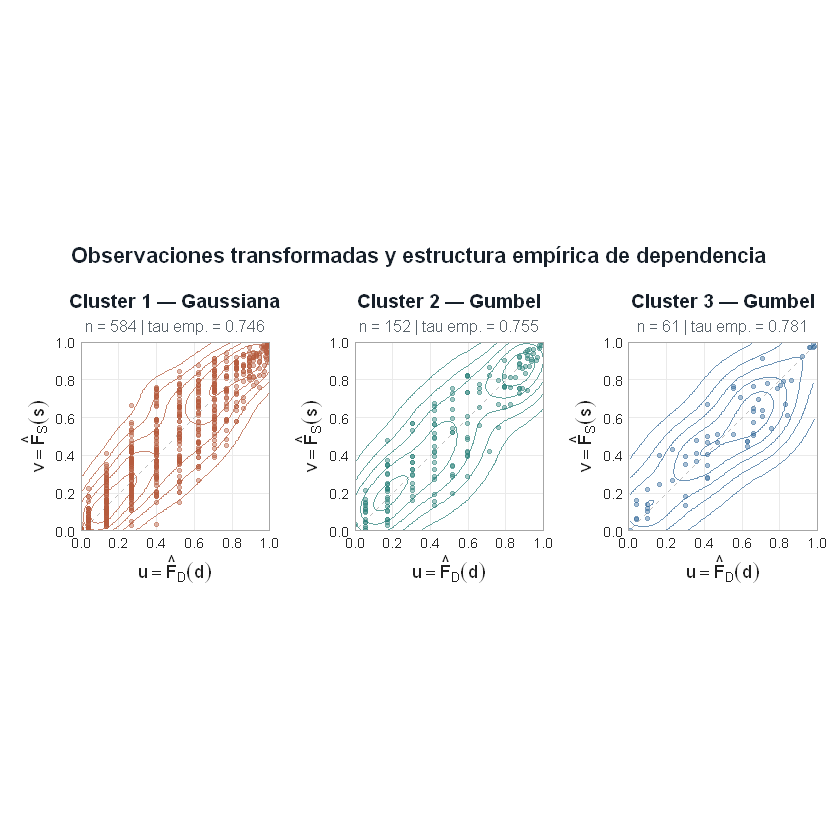

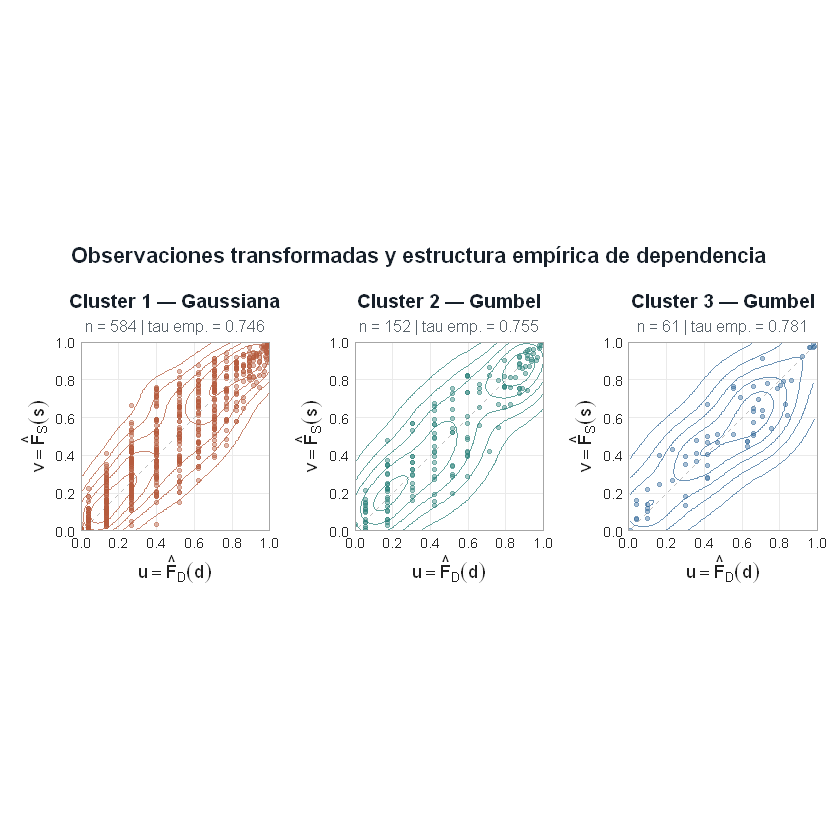

In [10]:
# ============================================================
# 10. FIGURA - OBSERVACIONES TRANSFORMADAS AL ESPACIO UNIFORME
#     VERSIÓN EDITORIAL / PUBLICACIÓN
# ============================================================

# ------------------------------------------------------------
# PALETA Y TEMA GENERAL DE FIGURAS
# ------------------------------------------------------------

col_clusters_fig <- c(
  "Cluster 1" = "#B45A3C",
  "Cluster 2" = "#287F78",
  "Cluster 3" = "#356A9A"
)

pal_densidad_fig <- grDevices::colorRampPalette(
  c(
    "#142F43",
    "#1E5B73",
    "#2E8290",
    "#6AAEA2",
    "#D4D7AD",
    "#F0C879",
    "#E99050",
    "#B84D37"
  )
)(256)

pal_cdf_fig <- grDevices::colorRampPalette(
  c(
    "#15324A",
    "#25678A",
    "#4A98B8",
    "#A2CAD8",
    "#F5F3E8",
    "#EFD18F",
    "#E69A58",
    "#B9583F"
  )
)(256)

theme_publicacion_copulas <- function(base_size = 10.8) {

  theme_minimal(base_size = base_size) +

    theme(
      panel.grid.minor = element_blank(),

      panel.grid.major = element_line(
        colour = "#EAEAEA",
        linewidth = 0.28
      ),

      panel.border = element_rect(
        fill = NA,
        colour = "#A6A6A6",
        linewidth = 0.45
      ),

      axis.title = element_text(
        face = "bold",
        colour = "#202020"
      ),

      axis.text = element_text(
        colour = "#262626"
      ),

      plot.title = element_text(
        face = "bold",
        size = 11.2,
        colour = "#17202A"
      ),

      plot.subtitle = element_text(
        size = 9.3,
        colour = "#59636B"
      ),

      legend.title = element_text(
        face = "bold"
      ),

      plot.margin = margin(
        7,
        8,
        7,
        8
      )
    )
}


guardar_gg_publicacion <- function(
  plot,
  nombre_base,
  width,
  height,
  dpi = 700
) {

  archivo_png <- file.path(
    ruta_figuras,
    paste0(
      nombre_base,
      ".png"
    )
  )

  archivo_pdf <- file.path(
    ruta_figuras,
    paste0(
      nombre_base,
      ".pdf"
    )
  )

  ggsave(
    filename = archivo_png,
    plot = plot,
    width = width,
    height = height,
    units = "in",
    dpi = dpi,
    bg = "white",
    limitsize = FALSE
  )

  pdf_ok <- tryCatch(
    {
      grDevices::pdf(
        archivo_pdf,
        width = width,
        height = height,
        useDingbats = FALSE,
        bg = "white"
      )

      print(
        plot
      )

      grDevices::dev.off()

      TRUE
    },
    error = function(e) {

      try(
        grDevices::dev.off(),
        silent = TRUE
      )

      warning(
        "No se pudo generar el PDF: ",
        conditionMessage(e)
      )

      FALSE
    }
  )

  invisible(
    c(
      png = archivo_png,
      pdf = if (pdf_ok) archivo_pdf else NA_character_
    )
  )
}


# ------------------------------------------------------------
# METADATOS PARA LOS TÍTULOS DE CADA PANEL
# ------------------------------------------------------------

meta_uv <- tabla_copulas_seleccionadas %>%

  arrange(
    cluster
  ) %>%

  mutate(
    n_eventos = c(
      nrow(pseudo_c1),
      nrow(pseudo_c2),
      nrow(pseudo_c3)
    ),

    familia_fig = dplyr::recode(
      familia,
      "Gaussian" = "Gaussiana",
      .default = familia
    ),

    titulo_panel = paste0(
      "Cluster ",
      cluster,
      " — ",
      familia_fig
    ),

    subtitulo_panel = paste0(
      "n = ",
      n_eventos,
      " | tau emp. = ",
      sprintf(
        "%.3f",
        tau_kendall_empirico
      )
    )
  )


crear_plot_uv <- function(
  df,
  cluster_id
) {

  fila <- meta_uv %>%
    filter(
      cluster == cluster_id
    )

  nombre_cluster <- paste0(
    "Cluster ",
    cluster_id
  )

  color_cluster <- unname(
    col_clusters_fig[
      nombre_cluster
    ]
  )

  ggplot(
    df,
    aes(
      x = u,
      y = v
    )
  ) +

    geom_abline(
      slope = 1,
      intercept = 0,
      linetype = "dashed",
      linewidth = 0.45,
      colour = "#BDBDBD"
    ) +

    stat_density_2d(
      colour = color_cluster,
      linewidth = 0.38,
      bins = 6,
      alpha = 0.72
    ) +

    geom_point(
      colour = color_cluster,
      alpha = 0.42,
      size = ifelse(
        cluster_id == 1,
        0.95,
        1.20
      )
    ) +

    coord_equal(
      xlim = c(
        0,
        1
      ),
      ylim = c(
        0,
        1
      ),
      expand = FALSE
    ) +

    scale_x_continuous(
      breaks = seq(
        0,
        1,
        0.2
      )
    ) +

    scale_y_continuous(
      breaks = seq(
        0,
        1,
        0.2
      )
    ) +

    labs(
      title = fila$titulo_panel[1],
      subtitle = fila$subtitulo_panel[1],
      x = expression(
        u == hat(F)[D](d)
      ),
      y = expression(
        v == hat(F)[S](s)
      )
    ) +

    theme_publicacion_copulas() +

    theme(
      plot.title = element_text(
        hjust = 0.5
      ),

      plot.subtitle = element_text(
        hjust = 0.5
      )
    )
}


p_uv_c1 <- crear_plot_uv(
  pseudo_c1,
  1
)

p_uv_c2 <- crear_plot_uv(
  pseudo_c2,
  2
)

p_uv_c3 <- crear_plot_uv(
  pseudo_c3,
  3
)


figura_uv <- (
  p_uv_c1 |
  p_uv_c2 |
  p_uv_c3
) +

  plot_annotation(
    title =
      "Observaciones transformadas y estructura empírica de dependencia",

    theme = theme(
      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = 13,
        colour = "#17202A",
        margin = margin(
          b = 8
        )
      )
    )
  )


print(
  figura_uv
)


# ------------------------------------------------------------
# GUARDAR FIGURA CONJUNTA
# ------------------------------------------------------------

guardar_gg_publicacion(
  figura_uv,
  "observaciones_uniformes_nspei3",
  width = 13.2,
  height = 4.7,
  dpi = 700
)


# ------------------------------------------------------------
# GUARDAR PANELES INDIVIDUALES
# ------------------------------------------------------------

guardar_gg_publicacion(
  p_uv_c1,
  "observaciones_uniformes_cluster1",
  width = 5.2,
  height = 4.8,
  dpi = 700
)

guardar_gg_publicacion(
  p_uv_c2,
  "observaciones_uniformes_cluster2",
  width = 5.2,
  height = 4.8,
  dpi = 700
)

guardar_gg_publicacion(
  p_uv_c3,
  "observaciones_uniformes_cluster3",
  width = 5.2,
  height = 4.8,
  dpi = 700
)


figura_uv


Warning message:
"The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead."


Figura 2D general e individuales generadas correctamente.


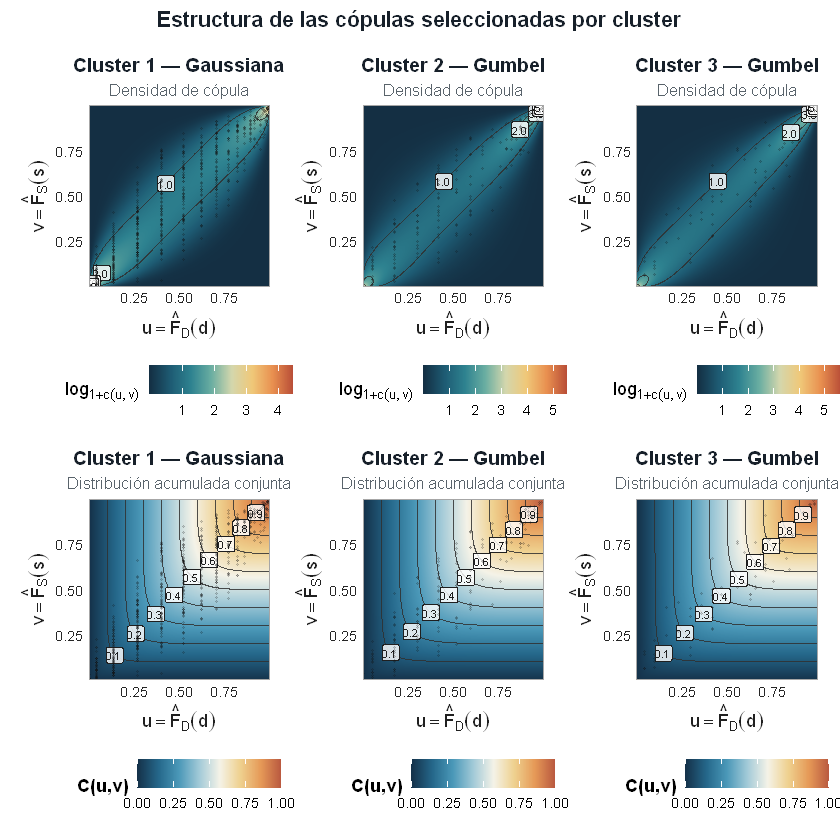

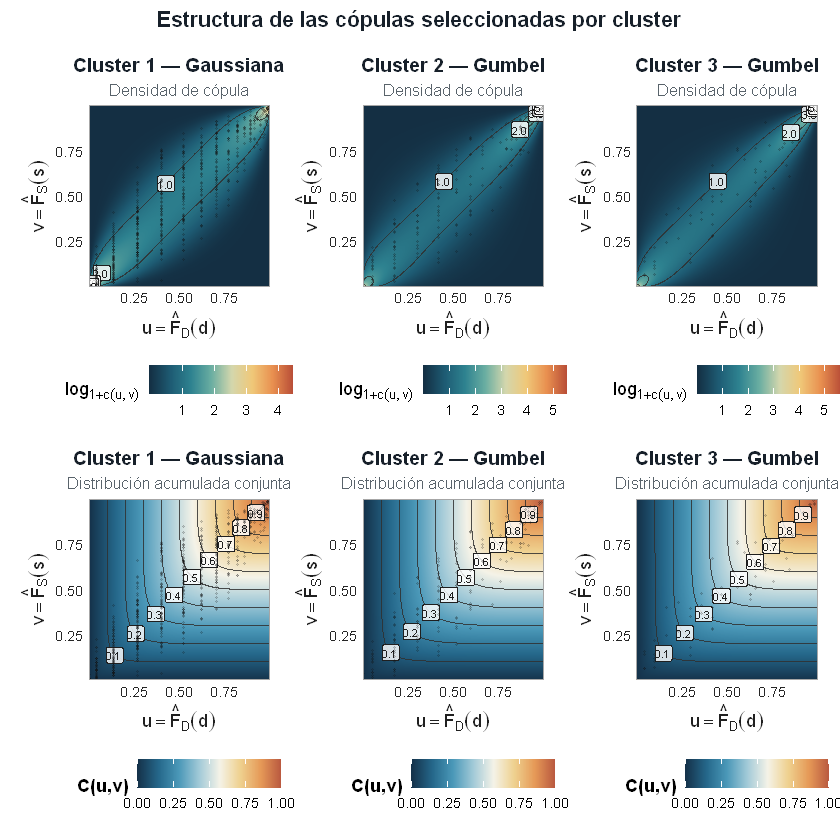

In [11]:
# ============================================================
# 11. SUPERFICIES BIDIMENSIONALES DE LAS CÓPULAS SELECCIONADAS
#     DENSIDAD + CDF, CON ISOLÍNEAS NUMÉRICAS
#     VERSIÓN ROBUSTA
# ============================================================

# ------------------------------------------------------------
# Función auxiliar:
# pCopula() puede fallar para tCopula si df no es entero.
# Para fines GRÁFICOS, se construye una versión equivalente
# con df redondeado al entero más cercano.
# ------------------------------------------------------------
copula_para_cdf <- function(cop) {

  if (inherits(cop, "tCopula")) {

    pars <- cop@parameters
    rho <- pars[1]
    df_val <- pars[2]

    if (!is.finite(df_val)) {
      df_val <- 30
    }

    df_plot <- max(2, round(df_val))

    return(
      tCopula(
        param = rho,
        dim = 2,
        dispstr = "un",
        df = df_plot,
        df.fixed = TRUE
      )
    )
  }

  cop
}


crear_superficie_copula <- function(
  fit,
  cluster_label,
  n_grid = 180
) {

  grid <- expand.grid(
    u = seq(0.003, 0.997, length.out = n_grid),
    v = seq(0.003, 0.997, length.out = n_grid)
  )

  cop_den <- fit@copula
  cop_cdf <- copula_para_cdf(fit@copula)

  uv_mat <- as.matrix(
    grid[, c("u", "v")]
  )

  dens <- tryCatch(
    dCopula(uv_mat, cop_den),
    error = function(e) {
      warning(
        "No fue posible calcular dCopula para ", cluster_label, ": ",
        conditionMessage(e)
      )
      rep(NA_real_, nrow(grid))
    }
  )

  cdfv <- tryCatch(
    pCopula(uv_mat, cop_cdf),
    error = function(e) {
      warning(
        "No fue posible calcular pCopula para ", cluster_label, ": ",
        conditionMessage(e)
      )
      rep(NA_real_, nrow(grid))
    }
  )

  dens[!is.finite(dens)] <- NA_real_
  cdfv[!is.finite(cdfv)] <- NA_real_

  as_tibble(grid) %>%
    mutate(
      C = cdfv,
      densidad = dens,
      log_densidad = log1p(pmax(densidad, 0)),
      cluster = cluster_label
    )
}


obtener_etiquetas_contorno <- function(
  surface_df,
  variable,
  niveles
) {

  df_ok <- surface_df %>%
    filter(is.finite(.data[[variable]]))

  if (nrow(df_ok) == 0 || length(niveles) == 0) {
    return(
      tibble(
        u = numeric(),
        v = numeric(),
        nivel = numeric(),
        longitud = integer()
      )
    )
  }

  u_vals <- sort(unique(df_ok$u))
  v_vals <- sort(unique(df_ok$v))

  z_mat <- matrix(
    df_ok[[variable]],
    nrow = length(u_vals),
    ncol = length(v_vals),
    byrow = FALSE
  )

  lineas <- grDevices::contourLines(
    x = u_vals,
    y = v_vals,
    z = z_mat,
    levels = niveles
  )

  if (length(lineas) == 0) {
    return(
      tibble(
        u = numeric(),
        v = numeric(),
        nivel = numeric(),
        longitud = integer()
      )
    )
  }

  purrr::map_dfr(
    lineas,
    function(obj) {
      idx <- max(1, ceiling(length(obj$x) / 2))
      tibble(
        u = obj$x[idx],
        v = obj$y[idx],
        nivel = obj$level,
        longitud = length(obj$x)
      )
    }
  ) %>%
    group_by(nivel) %>%
    slice_max(order_by = longitud, n = 1, with_ties = FALSE) %>%
    ungroup()
}


plot_densidad_2d <- function(
  surface_df,
  pseudo_df,
  familia,
  cluster_label
) {

  rango <- range(surface_df$log_densidad, finite = TRUE)

  niveles <- pretty(rango, n = 6)
  niveles <- niveles[niveles > rango[1] & niveles < rango[2]]

  etiquetas <- obtener_etiquetas_contorno(
    surface_df,
    "log_densidad",
    niveles
  )

  ggplot() +
    geom_raster(
      data = surface_df,
      aes(x = u, y = v, fill = log_densidad),
      interpolate = TRUE
    ) +
    geom_contour(
      data = surface_df,
      aes(x = u, y = v, z = log_densidad),
      breaks = niveles,
      colour = "#303030",
      linewidth = 0.35,
      alpha = 0.85
    ) +
    geom_label(
      data = etiquetas,
      aes(
        x = u,
        y = v,
        label = sprintf("%.1f", nivel)
      ),
      inherit.aes = FALSE,
      size = 2.3,
      label.size = 0.10,
      label.padding = grid::unit(0.08, "lines"),
      fill = grDevices::adjustcolor("white", alpha.f = 0.82),
      colour = "#1F1F1F"
    ) +
    geom_point(
      data = pseudo_df,
      aes(x = u, y = v),
      colour = "#0F0F0F",
      alpha = 0.16,
      size = 0.42
    ) +
    coord_equal(expand = FALSE) +
    scale_fill_gradientn(
      colours = pal_densidad_fig,
      name = expression(log[1 + c(u,v)])
    ) +
    labs(
      title = paste0(
        cluster_label, " — ",
        dplyr::recode(familia, "Gaussian" = "Gaussiana", .default = familia)
      ),
      subtitle = "Densidad de cópula",
      x = expression(u == hat(F)[D](d)),
      y = expression(v == hat(F)[S](s))
    ) +
    theme_publicacion_copulas() +
    theme(
      panel.grid = element_blank(),
      legend.position = "bottom",
      plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5)
    )
}


plot_cdf_2d <- function(
  surface_df,
  pseudo_df,
  familia,
  cluster_label
) {

  niveles <- seq(0.1, 0.9, by = 0.1)

  etiquetas <- obtener_etiquetas_contorno(
    surface_df,
    "C",
    niveles
  )

  ggplot() +
    geom_raster(
      data = surface_df,
      aes(x = u, y = v, fill = C),
      interpolate = TRUE
    ) +
    geom_contour(
      data = surface_df,
      aes(x = u, y = v, z = C),
      breaks = niveles,
      colour = "#303030",
      linewidth = 0.35,
      alpha = 0.85
    ) +
    geom_label(
      data = etiquetas,
      aes(
        x = u,
        y = v,
        label = sprintf("%.1f", nivel)
      ),
      inherit.aes = FALSE,
      size = 2.3,
      label.size = 0.10,
      label.padding = grid::unit(0.08, "lines"),
      fill = grDevices::adjustcolor("white", alpha.f = 0.82),
      colour = "#1F1F1F"
    ) +
    geom_point(
      data = pseudo_df,
      aes(x = u, y = v),
      colour = "#0F0F0F",
      alpha = 0.15,
      size = 0.40
    ) +
    coord_equal(expand = FALSE) +
    scale_fill_gradientn(
      colours = pal_cdf_fig,
      limits = c(0, 1),
      name = "C(u,v)"
    ) +
    labs(
      title = paste0(
        cluster_label, " — ",
        dplyr::recode(familia, "Gaussian" = "Gaussiana", .default = familia)
      ),
      subtitle = "Distribución acumulada conjunta",
      x = expression(u == hat(F)[D](d)),
      y = expression(v == hat(F)[S](s))
    ) +
    theme_publicacion_copulas() +
    theme(
      panel.grid = element_blank(),
      legend.position = "bottom",
      plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5)
    )
}


familias_sel <- tabla_copulas_seleccionadas %>%
  arrange(cluster) %>%
  pull(familia)

surf_c1 <- crear_superficie_copula(fits_seleccionados[[1]], "Cluster 1")
surf_c2 <- crear_superficie_copula(fits_seleccionados[[2]], "Cluster 2")
surf_c3 <- crear_superficie_copula(fits_seleccionados[[3]], "Cluster 3")

pd_c1 <- plot_densidad_2d(surf_c1, pseudo_c1, familias_sel[1], "Cluster 1")
pd_c2 <- plot_densidad_2d(surf_c2, pseudo_c2, familias_sel[2], "Cluster 2")
pd_c3 <- plot_densidad_2d(surf_c3, pseudo_c3, familias_sel[3], "Cluster 3")

p2d_c1 <- plot_cdf_2d(surf_c1, pseudo_c1, familias_sel[1], "Cluster 1")
p2d_c2 <- plot_cdf_2d(surf_c2, pseudo_c2, familias_sel[2], "Cluster 2")
p2d_c3 <- plot_cdf_2d(surf_c3, pseudo_c3, familias_sel[3], "Cluster 3")

figura_2d <- (
  (pd_c1 | pd_c2 | pd_c3) /
  (p2d_c1 | p2d_c2 | p2d_c3)
) +
  plot_annotation(
    title = "Estructura de las cópulas seleccionadas por cluster",
    theme = theme(
      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = 13,
        colour = "#17202A",
        margin = margin(b = 8)
      )
    )
  )

print(figura_2d)

guardar_gg_publicacion(
  figura_2d,
  "copulas_seleccionadas_2d_nspei3",
  width = 14.8,
  height = 9.3,
  dpi = 700
)

figura_densidad_2d <- (
  pd_c1 | pd_c2 | pd_c3
) +
  plot_annotation(
    title = "Densidad de las cópulas seleccionadas",
    theme = theme(
      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = 13,
        colour = "#17202A"
      )
    )
  )

guardar_gg_publicacion(
  figura_densidad_2d,
  "densidad_copulas_seleccionadas_2d_nspei3",
  width = 14.8,
  height = 5.1,
  dpi = 700
)

fig_c1_individual <- pd_c1 / p2d_c1
fig_c2_individual <- pd_c2 / p2d_c2
fig_c3_individual <- pd_c3 / p2d_c3

guardar_gg_publicacion(fig_c1_individual, "copula_2d_cluster1", width = 5.6, height = 9.0, dpi = 700)
guardar_gg_publicacion(fig_c2_individual, "copula_2d_cluster2", width = 5.6, height = 9.0, dpi = 700)
guardar_gg_publicacion(fig_c3_individual, "copula_2d_cluster3", width = 5.6, height = 9.0, dpi = 700)

cat("Figura 2D general e individuales generadas correctamente.\n")
figura_2d


In [12]:
# ============================================================
# 12. FIGURAS TRIDIMENSIONALES
#     VERSIÓN ROBUSTA
# ============================================================

colorear_superficie <- function(
  z_mat,
  zlim,
  paleta
) {

  z_centro <- (
    z_mat[-1, -1, drop = FALSE] +
    z_mat[-nrow(z_mat), -1, drop = FALSE] +
    z_mat[-1, -ncol(z_mat), drop = FALSE] +
    z_mat[-nrow(z_mat), -ncol(z_mat), drop = FALSE]
  ) / 4

  if (diff(zlim) <= 0 || any(!is.finite(zlim))) {
    indice <- matrix(
      ceiling(length(paleta) / 2),
      nrow = nrow(z_centro),
      ncol = ncol(z_centro)
    )
  } else {
    indice <- floor(((z_centro - zlim[1]) / diff(zlim)) * (length(paleta) - 1)) + 1
    indice <- pmax(1, pmin(length(paleta), indice))
  }

  matrix(
    paleta[indice],
    nrow = nrow(z_centro),
    ncol = ncol(z_centro)
  )
}


dibujar_contornos_proyectados <- function(
  x_vals,
  y_vals,
  z_mat,
  niveles,
  z_base,
  pmat,
  color = "#713B2B"
) {

  curvas <- tryCatch(
    grDevices::contourLines(
      x = x_vals,
      y = y_vals,
      z = z_mat,
      levels = niveles
    ),
    error = function(e) list()
  )

  if (length(curvas) == 0) {
    return(invisible(NULL))
  }

  for (obj in curvas) {
    pp <- trans3d(
      x = obj$x,
      y = obj$y,
      z = rep(z_base, length(obj$x)),
      pmat = pmat
    )

    lines(pp$x, pp$y, col = color, lwd = 0.85)
  }

  niveles_etiqueta <- unique(
    niveles[
      round(
        seq(1, length(niveles), length.out = min(3, length(niveles)))
      )
    ]
  )

  curvas_etiqueta <- tryCatch(
    grDevices::contourLines(
      x = x_vals,
      y = y_vals,
      z = z_mat,
      levels = niveles_etiqueta
    ),
    error = function(e) list()
  )

  for (obj in curvas_etiqueta) {
    idx <- max(1, ceiling(length(obj$x) / 2))
    tt <- trans3d(
      x = obj$x[idx],
      y = obj$y[idx],
      z = z_base,
      pmat = pmat
    )

    text(
      tt$x,
      tt$y,
      labels = sprintf("%.2f", obj$level),
      cex = 0.52,
      col = color,
      pos = 3
    )
  }

  invisible(NULL)
}


guardar_superficie_3d <- function(
  surface_df,
  pseudo_df,
  fit,
  familia,
  cluster_label,
  archivo_png,
  archivo_html
) {

  df_ok <- surface_df %>%
    filter(
      is.finite(log_densidad),
      is.finite(C)
    )

  u_vals <- sort(unique(df_ok$u))
  v_vals <- sort(unique(df_ok$v))

  z_cdf <- matrix(df_ok$C, nrow = length(u_vals), ncol = length(v_vals), byrow = FALSE)
  z_den <- matrix(df_ok$log_densidad, nrow = length(u_vals), ncol = length(v_vals), byrow = FALSE)

  rango_den <- range(z_den, finite = TRUE)
  rango_cdf <- c(0, 1)

  niveles_den <- pretty(rango_den, n = 6)
  niveles_den <- niveles_den[niveles_den > rango_den[1] & niveles_den < rango_den[2]]
  niveles_cdf <- seq(0.1, 0.9, by = 0.1)

  cols_den <- colorear_superficie(z_den, rango_den, pal_densidad_fig)
  cols_cdf <- colorear_superficie(z_cdf, rango_cdf, pal_cdf_fig)

  familia_fig <- dplyr::recode(
    familia,
    "Gaussian" = "Gaussiana",
    .default = familia
  )

  cop_cdf <- copula_para_cdf(fit@copula)

  z_pts <- tryCatch(
    pCopula(as.matrix(pseudo_df[, c("u", "v")]), cop_cdf),
    error = function(e) rep(NA_real_, nrow(pseudo_df))
  )

  # ============================
  # PNG
  # ============================
  png(archivo_png, width = 3000, height = 2600, res = 340, bg = "white")

  op <- par(no.readonly = TRUE)

  layout(matrix(1:4, nrow = 2, ncol = 2, byrow = TRUE), widths = c(1.12, 1.00))
  par(
    oma = c(1.8, 1.6, 4.0, 0.6),
    mar = c(3.0, 3.0, 2.0, 1.0),
    mgp = c(1.85, 0.58, 0),
    cex.axis = 0.72,
    cex.lab = 0.78
  )

  zbase_den <- rango_den[1]
  pm_den <- persp(
    x = u_vals, y = v_vals, z = z_den,
    zlim = rango_den,
    theta = 42, phi = 28,
    expand = 0.83, shade = 0.34, ltheta = 120,
    col = cols_den, border = "#FFFFFF45",
    ticktype = "detailed",
    xlab = "u", ylab = "v", zlab = "log[1+c(u,v)]",
    main = "Densidad", cex.axis = 0.66, cex.lab = 0.70
  )

  dibujar_contornos_proyectados(u_vals, v_vals, z_den, niveles_den, zbase_den, pm_den, color = "#6D392A")

  image(
    x = u_vals, y = v_vals, z = z_den,
    zlim = rango_den,
    col = pal_densidad_fig,
    useRaster = TRUE, axes = FALSE,
    xlab = "u", ylab = "v", main = "Densidad e isolíneas"
  )
  axis(1, at = seq(0, 1, 0.2))
  axis(2, at = seq(0, 1, 0.2), las = 1)
  contour(
    u_vals, v_vals, z_den,
    levels = niveles_den,
    add = TRUE, drawlabels = TRUE,
    col = "#2D2D2D", lwd = 0.80, labcex = 0.66
  )
  box(col = "#606060")

  zbase_cdf <- 0
  pm_cdf <- persp(
    x = u_vals, y = v_vals, z = z_cdf,
    zlim = rango_cdf,
    theta = 42, phi = 28,
    expand = 0.83, shade = 0.32, ltheta = 120,
    col = cols_cdf, border = "#FFFFFF45",
    ticktype = "detailed",
    xlab = "u", ylab = "v", zlab = "C(u,v)",
    main = "Distribución acumulada",
    cex.axis = 0.66, cex.lab = 0.70
  )

  dibujar_contornos_proyectados(u_vals, v_vals, z_cdf, niveles_cdf, zbase_cdf, pm_cdf, color = "#5B4A34")

  pts <- trans3d(
    x = pseudo_df$u,
    y = pseudo_df$v,
    z = ifelse(is.finite(z_pts), z_pts, 0),
    pmat = pm_cdf
  )
  points(pts$x, pts$y, pch = 16, cex = 0.24, col = grDevices::adjustcolor("#151515", alpha.f = 0.35))

  image(
    x = u_vals, y = v_vals, z = z_cdf,
    zlim = rango_cdf,
    col = pal_cdf_fig,
    useRaster = TRUE, axes = FALSE,
    xlab = "u", ylab = "v", main = "Distribución acumulada e isolíneas"
  )
  axis(1, at = seq(0, 1, 0.2))
  axis(2, at = seq(0, 1, 0.2), las = 1)
  contour(
    u_vals, v_vals, z_cdf,
    levels = niveles_cdf,
    add = TRUE, drawlabels = TRUE,
    col = "#2D2D2D", lwd = 0.80, labcex = 0.66
  )
  points(pseudo_df$u, pseudo_df$v, pch = 16, cex = 0.22, col = grDevices::adjustcolor("#111111", alpha.f = 0.25))
  box(col = "#606060")

  mtext(
    paste0(cluster_label, " — Cópula ", familia_fig),
    side = 3, outer = TRUE, line = 2.0, cex = 1.15, font = 2, col = "#17202A"
  )
  mtext(
    "Representación de densidad y distribución acumulada",
    side = 3, outer = TRUE, line = 0.55, cex = 0.82, col = "#5A636A"
  )

  par(op)
  dev.off()

  # ============================
  # PDF
  # ============================
  archivo_pdf <- sub("\\.png$", ".pdf", archivo_png)

  tryCatch(
    {
      grDevices::pdf(archivo_pdf, width = 9.0, height = 7.8, useDingbats = FALSE, bg = "white")

      op <- par(no.readonly = TRUE)
      layout(matrix(1:4, nrow = 2, ncol = 2, byrow = TRUE), widths = c(1.12, 1.00))
      par(
        oma = c(1.8, 1.6, 4.0, 0.6),
        mar = c(3.0, 3.0, 2.0, 1.0),
        mgp = c(1.85, 0.58, 0),
        cex.axis = 0.72,
        cex.lab = 0.78
      )

      pm_den <- persp(
        x = u_vals, y = v_vals, z = z_den,
        zlim = rango_den,
        theta = 42, phi = 28,
        expand = 0.83, shade = 0.34, ltheta = 120,
        col = cols_den, border = "#FFFFFF45",
        ticktype = "detailed",
        xlab = "u", ylab = "v", zlab = "log[1+c(u,v)]",
        main = "Densidad"
      )
      dibujar_contornos_proyectados(u_vals, v_vals, z_den, niveles_den, zbase_den, pm_den, color = "#6D392A")

      image(u_vals, v_vals, z_den, zlim = rango_den, col = pal_densidad_fig, useRaster = TRUE, xlab = "u", ylab = "v", main = "Densidad e isolíneas")
      contour(u_vals, v_vals, z_den, levels = niveles_den, add = TRUE, drawlabels = TRUE, col = "#2D2D2D", lwd = 0.80, labcex = 0.66)

      pm_cdf <- persp(
        x = u_vals, y = v_vals, z = z_cdf,
        zlim = rango_cdf,
        theta = 42, phi = 28,
        expand = 0.83, shade = 0.32, ltheta = 120,
        col = cols_cdf, border = "#FFFFFF45",
        ticktype = "detailed",
        xlab = "u", ylab = "v", zlab = "C(u,v)",
        main = "Distribución acumulada"
      )
      dibujar_contornos_proyectados(u_vals, v_vals, z_cdf, niveles_cdf, zbase_cdf, pm_cdf, color = "#5B4A34")

      pts <- trans3d(x = pseudo_df$u, y = pseudo_df$v, z = ifelse(is.finite(z_pts), z_pts, 0), pmat = pm_cdf)
      points(pts$x, pts$y, pch = 16, cex = 0.24, col = grDevices::adjustcolor("#151515", alpha.f = 0.35))

      image(u_vals, v_vals, z_cdf, zlim = rango_cdf, col = pal_cdf_fig, useRaster = TRUE, xlab = "u", ylab = "v", main = "Distribución acumulada e isolíneas")
      contour(u_vals, v_vals, z_cdf, levels = niveles_cdf, add = TRUE, drawlabels = TRUE, col = "#2D2D2D", lwd = 0.80, labcex = 0.66)
      points(pseudo_df$u, pseudo_df$v, pch = 16, cex = 0.22, col = grDevices::adjustcolor("#111111", alpha.f = 0.25))

      mtext(paste0(cluster_label, " — Cópula ", familia_fig), side = 3, outer = TRUE, line = 2.0, cex = 1.15, font = 2)
      mtext("Representación de densidad y distribución acumulada", side = 3, outer = TRUE, line = 0.55, cex = 0.82)

      par(op)
      grDevices::dev.off()
    },
    error = function(e) {
      try(grDevices::dev.off(), silent = TRUE)
      warning("No se pudo generar el PDF de ", cluster_label, ": ", conditionMessage(e))
    }
  )

  # ============================
  # HTML interactivo
  # ============================
  tryCatch(
    {
      fig_html <- plot_ly() %>%
        add_surface(
          x = ~u_vals,
          y = ~v_vals,
          z = ~z_cdf,
          opacity = 0.96,
          showscale = TRUE,
          colorscale = list(
            c(0.00, "#15324A"),
            c(0.20, "#25678A"),
            c(0.40, "#4A98B8"),
            c(0.58, "#F5F3E8"),
            c(0.76, "#EFD18F"),
            c(1.00, "#B9583F")
          ),
          contours = list(
            z = list(
              show = TRUE,
              usecolormap = FALSE,
              color = "#4B4036",
              width = 2,
              project = list(z = TRUE)
            )
          ),
          colorbar = list(title = "C(u,v)"),
          name = "C(u,v)"
        ) %>%
        add_markers(
          x = pseudo_df$u,
          y = pseudo_df$v,
          z = ifelse(is.finite(z_pts), z_pts, 0),
          marker = list(size = 2.4, color = "#161616", opacity = 0.45),
          name = "Observaciones transformadas"
        ) %>%
        layout(
          title = list(
            text = paste0(cluster_label, " | Cópula ", familia_fig),
            x = 0.5
          ),
          scene = list(
            xaxis = list(title = "u = F_D(d)", backgroundcolor = "white", gridcolor = "#DDDDDD"),
            yaxis = list(title = "v = F_S(s)", backgroundcolor = "white", gridcolor = "#DDDDDD"),
            zaxis = list(title = "C(u,v)", backgroundcolor = "white", gridcolor = "#DDDDDD"),
            camera = list(eye = list(x = 1.45, y = 1.45, z = 1.05))
          ),
          paper_bgcolor = "white",
          plot_bgcolor = "white"
        )

      htmlwidgets::saveWidget(fig_html, archivo_html, selfcontained = FALSE)
    },
    error = function(e) {
      warning("No se pudo generar el HTML de ", cluster_label, ": ", conditionMessage(e))
    }
  )

  invisible(TRUE)
}


guardar_superficie_3d(
  surf_c1, pseudo_c1, fits_seleccionados[[1]], familias_sel[1],
  "Cluster 1",
  file.path(ruta_figuras, "copula_3d_cluster1.png"),
  file.path(ruta_figuras, "copula_3d_cluster1.html")
)

guardar_superficie_3d(
  surf_c2, pseudo_c2, fits_seleccionados[[2]], familias_sel[2],
  "Cluster 2",
  file.path(ruta_figuras, "copula_3d_cluster2.png"),
  file.path(ruta_figuras, "copula_3d_cluster2.html")
)

guardar_superficie_3d(
  surf_c3, pseudo_c3, fits_seleccionados[[3]], familias_sel[3],
  "Cluster 3",
  file.path(ruta_figuras, "copula_3d_cluster3.png"),
  file.path(ruta_figuras, "copula_3d_cluster3.html")
)

cat("Figuras 3D sofisticadas generadas en PNG, PDF y HTML.\n")


Figuras 3D sofisticadas generadas en PNG, PDF y HTML.


In [13]:
# Resumen de familias utilizadas en las figuras.
tibble(
  cluster = 1:3,
  familia = familias_sel
)


cluster,familia
<int>,<chr>
1,Gaussian
2,Gumbel
3,Gumbel


In [14]:
# Medidas de dependencia de las cópulas seleccionadas.
medidas_dependencia


cluster,tau_kendall_empirico,tau_kendall_modelo,lambda_inferior,lambda_superior
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7459260,0.7182645,0,0.0000000
2,0.7547299,0.7107253,0,0.7779743
3,0.7813160,0.7369506,0,0.7999875


In [15]:
# ============================================================
# 13. VERIFICACIÓN FINAL DE SALIDAS
# ============================================================

salidas <- c(
  file.path(ruta_tablas, "eventos_ajuste_bivariado_nspei3.csv"),
  file.path(ruta_tablas, "diagnostico_transformacion_uniforme_nspei3.csv"),
  file.path(ruta_tablas, "comparacion_copulas_nspei3.csv"),
  file.path(ruta_tablas, "copulas_seleccionadas_nspei3.csv"),
  file.path(ruta_figuras, "observaciones_uniformes_nspei3.png"),
  file.path(ruta_figuras, "copulas_seleccionadas_2d_nspei3.png"),
  file.path(ruta_figuras, "copula_2d_cluster1.png"),
  file.path(ruta_figuras, "copula_2d_cluster2.png"),
  file.path(ruta_figuras, "copula_2d_cluster3.png"),
  file.path(ruta_figuras, "copula_3d_cluster1.png"),
  file.path(ruta_figuras, "copula_3d_cluster2.png"),
  file.path(ruta_figuras, "copula_3d_cluster3.png"),
  file.path(ruta_figuras, "copula_3d_cluster1.html"),
  file.path(ruta_figuras, "copula_3d_cluster2.html"),
  file.path(ruta_figuras, "copula_3d_cluster3.html")
)

verificacion <- tibble(
  archivo = basename(salidas),
  existe = file.exists(salidas),
  tamaño_bytes = file.info(salidas)$size
)

cat("\n=== VERIFICACIÓN FINAL ===\n")
print(verificacion, n = Inf, width = Inf)



=== VERIFICACIÓN FINAL ===
# A tibble: 15 × 3
   archivo                                        existe tamaño_bytes
   <chr>                                          <lgl>         <dbl>
 1 eventos_ajuste_bivariado_nspei3.csv            TRUE             87
 2 diagnostico_transformacion_uniforme_nspei3.csv TRUE            401
 3 comparacion_copulas_nspei3.csv                 TRUE           1461
 4 copulas_seleccionadas_nspei3.csv               TRUE            709
 5 observaciones_uniformes_nspei3.png             TRUE        2114417
 6 copulas_seleccionadas_2d_nspei3.png            TRUE        3936618
 7 copula_2d_cluster1.png                         TRUE        1662838
 8 copula_2d_cluster2.png                         TRUE        1325054
 9 copula_2d_cluster3.png                         TRUE        1218777
10 copula_3d_cluster1.png                         TRUE         728164
11 copula_3d_cluster2.png                         TRUE         690855
12 copula_3d_cluster3.png                  